# Gradient Boosting and Model Optimization

The baseline modeling notebook established three reference models:

- Dummy Regression
- Ridge Regression
- Random Forest Regression

Random Forest achieved the strongest baseline performance, indicating
that nonlinear degradation patterns are important for RUL prediction.

This notebook evaluates gradient boosting as a more sequential and
error-focused ensemble method.

The objectives are to:

- build an untuned gradient-boosting baseline,
- compare it fairly with the previous models,
- evaluate whether additional complexity provides meaningful value,
- and perform only limited optimization when justified by validation
  performance.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import GroupShuffleSplit

from xgboost import XGBRegressor

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import EMA_SPAN, ROLLING_WINDOW
from src.data_loader import load_cmapss_data
from src.preprocessing import add_sensor_history_features
from src.rul_builder import add_train_rul

## Reproduce the Baseline Modeling Dataset

To ensure a fair comparison, this notebook recreates the same
leakage-safe dataset and engine-level validation split used in
Notebook 04.

The same:

- selected sensors,
- historical feature definitions,
- configuration values,
- random seed,
- and validation engines

are preserved.

This ensures that performance differences are caused by the model
rather than by changes in the dataset or split.

In [2]:
train_path = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "train_FD001.txt"
)

df = load_cmapss_data(train_path)
df = add_train_rul(df)

In [3]:
selected_sensors = [
    "s2",
    "s3",
    "s4",
    "s7",
    "s11",
    "s12",
    "s15",
    "s17",
    "s20",
    "s21",
]

In [4]:
modeling_df = add_sensor_history_features(
    df,
    sensors=selected_sensors,
    rolling_window=ROLLING_WINDOW,
    ema_span=EMA_SPAN,
).reset_index(drop=True)

In [5]:
historical_features = [
    f"{sensor}_{suffix}"
    for sensor in selected_sensors
    for suffix in [
        "diff_1",
        f"rolling_mean_{ROLLING_WINDOW}",
        f"ema_{EMA_SPAN}",
        "expanding_mean",
    ]
]

feature_columns = (
    ["cycle"]
    + selected_sensors
    + historical_features
)

target_column = "RUL"
group_column = "id"

In [6]:
group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42,
)

train_indices, validation_indices = next(
    group_splitter.split(
        modeling_df,
        groups=modeling_df[group_column],
    )
)

train_df = (
    modeling_df
    .iloc[train_indices]
    .reset_index(drop=True)
)

validation_df = (
    modeling_df
    .iloc[validation_indices]
    .reset_index(drop=True)
)

X_train = train_df[feature_columns]
y_train = train_df[target_column]

X_validation = validation_df[feature_columns]
y_validation = validation_df[target_column]

In [7]:
train_engines = set(train_df["id"].unique())
validation_engines = set(validation_df["id"].unique())

assert train_engines.isdisjoint(validation_engines)
assert len(train_engines) == 80
assert len(validation_engines) == 20
assert X_train.isna().sum().sum() == 0
assert X_validation.isna().sum().sum() == 0

print("Gradient boosting dataset prepared successfully.")

Gradient boosting dataset prepared successfully.


In [8]:
reference_results = pd.DataFrame(
    [
        {
            "model": "Dummy Mean",
            "MAE": 55.363,
            "RMSE": 65.715,
            "R2": -0.002,
        },
        {
            "model": "Ridge",
            "MAE": 28.018,
            "RMSE": 35.823,
            "R2": 0.702,
        },
        {
            "model": "Random Forest",
            "MAE": 20.502,
            "RMSE": 27.197,
            "R2": 0.828,
        },
    ]
)

reference_results

,model,MAE,RMSE,R2
0,Dummy Mean,55.363,65.715,-0.002
1,Ridge,28.018,35.823,0.702
2,Random Forest,20.502,27.197,0.828


The baseline values below were produced in Notebook 04 using the same
engine-level split.

They are recorded here as fixed reference results so that the gradient
boosting model can be compared against the previously validated
baselines.

Future versions of the project may persist experiment results to disk
instead of entering them manually.

## Histogram Gradient Boosting Baseline

Histogram Gradient Boosting builds trees sequentially.

Each new tree focuses on correcting errors made by the existing
ensemble, unlike Random Forest where trees are trained more
independently and then averaged.

This initial model is intentionally lightly configured. The purpose is
to measure its untuned value before performing any systematic
optimization.

### Early-Stopping Policy

The initial experiment used the estimator's internal early-stopping
mechanism.

However, its internal validation split is not group-aware and may place
cycles from the same engine in both internal training and validation
subsets.

To preserve the engine-level separation policy used throughout the
project, internal early stopping is disabled for this baseline.

Any later optimization will use explicitly separated engine groups
rather than a random row-level validation fraction.

In [9]:
hist_gradient_boosting_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    early_stopping=False,
    random_state=42,
)

In [10]:
hist_gradient_boosting_model.fit(
    X_train,
    y_train,
)

hgb_predictions = hist_gradient_boosting_model.predict(
    X_validation
)

In [11]:
print("Completed boosting iterations:")
print(hist_gradient_boosting_model.n_iter_)

print("\nPrediction range:")
print("Minimum:", hgb_predictions.min())
print("Maximum:", hgb_predictions.max())

assert len(hgb_predictions) == len(y_validation)
assert np.isfinite(hgb_predictions).all()
assert len(np.unique(hgb_predictions)) > 1

Completed boosting iterations:
300

Prediction range:
Minimum: 1.6926171441851834
Maximum: 271.39557666021454


In [12]:
negative_hgb_predictions = (
    hgb_predictions < 0
).sum()

print(
    "Negative gradient boosting predictions:",
    negative_hgb_predictions,
)

Negative gradient boosting predictions: 0


In [13]:
hgb_mae = mean_absolute_error(
    y_validation,
    hgb_predictions,
)

hgb_rmse = root_mean_squared_error(
    y_validation,
    hgb_predictions,
)

hgb_r2 = r2_score(
    y_validation,
    hgb_predictions,
)

print(f"HistGradientBoosting MAE:  {hgb_mae:.3f}")
print(f"HistGradientBoosting RMSE: {hgb_rmse:.3f}")
print(f"HistGradientBoosting R²:   {hgb_r2:.3f}")

HistGradientBoosting MAE:  21.295
HistGradientBoosting RMSE: 29.399
HistGradientBoosting R²:   0.799


In [14]:
hgb_result = pd.DataFrame(
    [
        {
            "model": "HistGradientBoosting",
            "MAE": hgb_mae,
            "RMSE": hgb_rmse,
            "R2": hgb_r2,
        }
    ]
)

model_comparison = pd.concat(
    [
        reference_results,
        hgb_result,
    ],
    ignore_index=True,
).sort_values(
    "MAE"
).reset_index(drop=True)

model_comparison

,model,MAE,RMSE,R2
0,Random Forest,20.502000,27.197000,0.828000
1,HistGradientBoosting,21.294995,29.398698,0.799478
2,Ridge,28.018000,35.823000,0.702000
3,Dummy Mean,55.363000,65.715000,-0.002000


In [15]:
random_forest_mae = 20.502
random_forest_rmse = 27.197

hgb_mae_change_vs_rf = (
    (random_forest_mae - hgb_mae)
    / random_forest_mae
    * 100
)

hgb_rmse_change_vs_rf = (
    (random_forest_rmse - hgb_rmse)
    / random_forest_rmse
    * 100
)

print(
    f"MAE improvement over Random Forest: "
    f"{hgb_mae_change_vs_rf:.2f}%"
)

print(
    f"RMSE improvement over Random Forest: "
    f"{hgb_rmse_change_vs_rf:.2f}%"
)

MAE improvement over Random Forest: -3.87%
RMSE improvement over Random Forest: -8.10%


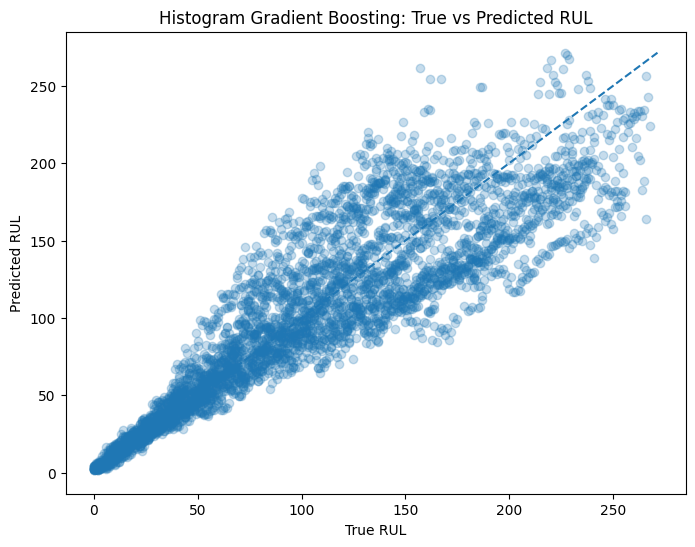

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_validation,
    hgb_predictions,
    alpha=0.25,
)

minimum_value = min(
    y_validation.min(),
    hgb_predictions.min(),
)

maximum_value = max(
    y_validation.max(),
    hgb_predictions.max(),
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
)

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title(
    "Histogram Gradient Boosting: "
    "True vs Predicted RUL"
)
plt.show()

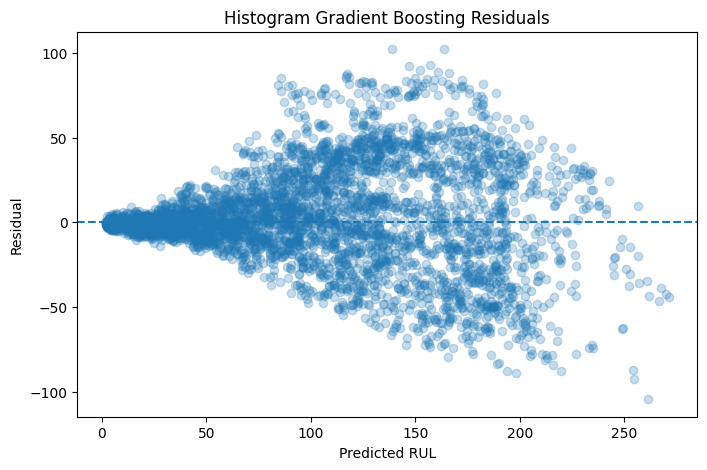

In [17]:
hgb_residuals = (
    y_validation.to_numpy()
    - hgb_predictions
)

plt.figure(figsize=(8, 5))

plt.scatter(
    hgb_predictions,
    hgb_residuals,
    alpha=0.25,
)

plt.axhline(
    y=0,
    linestyle="--",
)

plt.xlabel("Predicted RUL")
plt.ylabel("Residual")
plt.title("Histogram Gradient Boosting Residuals")
plt.show()

## XGBoost Baseline

XGBoost is an optimized gradient-boosted tree algorithm widely used for
tabular regression problems.

Unlike Random Forest, where trees are trained more independently and
their predictions are averaged, XGBoost builds trees sequentially.

Each new tree focuses on correcting the residual errors of the existing
ensemble.

This experiment uses the same:

- modeling features,
- engine-level training and validation split,
- target definition,
- and evaluation metrics

as the previous models.

The objective is to evaluate one standard XGBoost configuration, not to
perform extensive hyperparameter optimization.

In [18]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

In [19]:
xgb_model.fit(
    X_train,
    y_train,
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [20]:
xgb_predictions = xgb_model.predict(
    X_validation
)

In [21]:
print("First XGBoost predictions:")
print(xgb_predictions[:5])

print("\nPrediction range:")
print("Minimum:", xgb_predictions.min())
print("Maximum:", xgb_predictions.max())

First XGBoost predictions:
[193.21904 218.88622 185.96823 188.8232  241.2478 ]

Prediction range:
Minimum: 0.6795475
Maximum: 271.6671


In [22]:
assert len(xgb_predictions) == len(y_validation)

assert np.isfinite(xgb_predictions).all(), (
    "XGBoost predictions must not contain NaN or infinite values."
)

assert len(np.unique(xgb_predictions)) > 1, (
    "XGBoost should not produce constant predictions."
)

In [23]:
negative_xgb_predictions = (
    xgb_predictions < 0
).sum()

negative_xgb_percentage = (
    negative_xgb_predictions
    / len(xgb_predictions)
    * 100
)

print(
    "Negative XGBoost predictions:",
    negative_xgb_predictions,
)

print(
    f"Negative prediction percentage: "
    f"{negative_xgb_percentage:.2f}%"
)

Negative XGBoost predictions: 0
Negative prediction percentage: 0.00%


In [24]:
xgb_mae = mean_absolute_error(
    y_validation,
    xgb_predictions,
)

xgb_rmse = root_mean_squared_error(
    y_validation,
    xgb_predictions,
)

xgb_r2 = r2_score(
    y_validation,
    xgb_predictions,
)

print(f"XGBoost MAE:  {xgb_mae:.3f}")
print(f"XGBoost RMSE: {xgb_rmse:.3f}")
print(f"XGBoost R²:   {xgb_r2:.3f}")

XGBoost MAE:  21.105
XGBoost RMSE: 29.079
XGBoost R²:   0.804


In [25]:
random_forest_mae = 20.502
random_forest_rmse = 27.197

xgb_mae_improvement_vs_rf = (
    (random_forest_mae - xgb_mae)
    / random_forest_mae
    * 100
)

xgb_rmse_improvement_vs_rf = (
    (random_forest_rmse - xgb_rmse)
    / random_forest_rmse
    * 100
)

print(
    f"MAE improvement over Random Forest: "
    f"{xgb_mae_improvement_vs_rf:.2f}%"
)

print(
    f"RMSE improvement over Random Forest: "
    f"{xgb_rmse_improvement_vs_rf:.2f}%"
)

MAE improvement over Random Forest: -2.94%
RMSE improvement over Random Forest: -6.92%


In [26]:
xgb_result = pd.DataFrame(
    [
        {
            "model": "XGBoost",
            "MAE": xgb_mae,
            "RMSE": xgb_rmse,
            "R2": xgb_r2,
        }
    ]
)

model_comparison = pd.concat(
    [
        model_comparison,
        xgb_result,
    ],
    ignore_index=True,
)

model_comparison = (
    model_comparison
    .sort_values("MAE")
    .reset_index(drop=True)
)

model_comparison

,model,MAE,RMSE,R2
0,Random Forest,20.502000,27.197000,0.828000
1,XGBoost,21.105051,29.079475,0.803809
2,HistGradientBoosting,21.294995,29.398698,0.799478
3,Ridge,28.018000,35.823000,0.702000
4,Dummy Mean,55.363000,65.715000,-0.002000


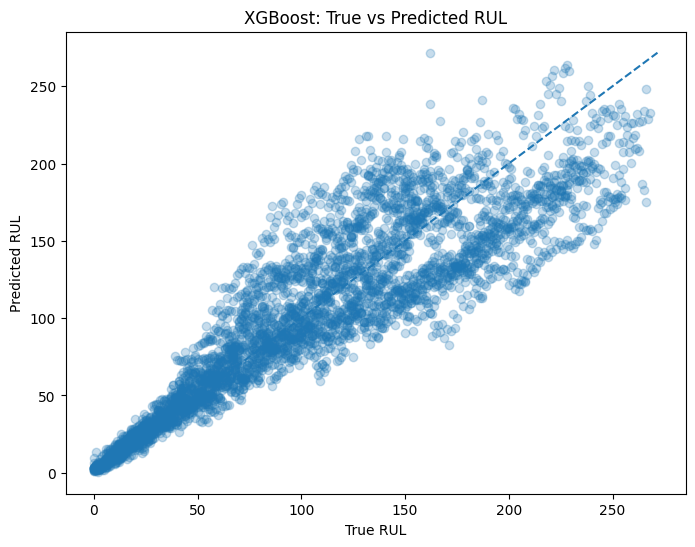

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_validation,
    xgb_predictions,
    alpha=0.25,
)

minimum_value = min(
    y_validation.min(),
    xgb_predictions.min(),
)

maximum_value = max(
    y_validation.max(),
    xgb_predictions.max(),
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
)

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("XGBoost: True vs Predicted RUL")
plt.show()

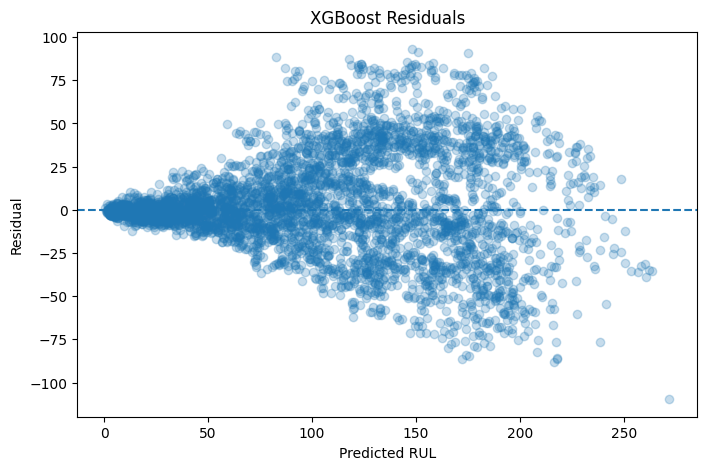

In [28]:
xgb_residuals = (
    y_validation.to_numpy()
    - xgb_predictions
)

plt.figure(figsize=(8, 5))

plt.scatter(
    xgb_predictions,
    xgb_residuals,
    alpha=0.25,
)

plt.axhline(
    y=0,
    linestyle="--",
)

plt.xlabel("Predicted RUL")
plt.ylabel("Residual")
plt.title("XGBoost Residuals")
plt.show()

In [29]:
xgb_feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_columns,
).sort_values(
    ascending=False
)

xgb_feature_importance.head(20)

cycle                 0.146549
s4_ema_5              0.146188
s11_ema_5             0.128695
s4_rolling_mean_5     0.092873
s11_rolling_mean_5    0.061532
s15_ema_5             0.043541
s21_ema_5             0.041505
s15_rolling_mean_5    0.034393
s21_rolling_mean_5    0.033919
s3_ema_5              0.024750
s20_expanding_mean    0.017353
s17_expanding_mean    0.016686
s12_expanding_mean    0.016561
s15_expanding_mean    0.014523
s2_expanding_mean     0.014336
s3_rolling_mean_5     0.014221
s11_expanding_mean    0.014174
s2_rolling_mean_5     0.011606
s17_ema_5             0.011226
s17_rolling_mean_5    0.010827
dtype: float32

### XGBoost Feature Importance Note

XGBoost feature importance indicates how strongly features contributed
to tree construction within this fitted model.

These values are useful for exploratory comparison, but they are not
causal explanations.

Correlated raw, rolling, EMA, and expanding features may divide
importance across several related variables.

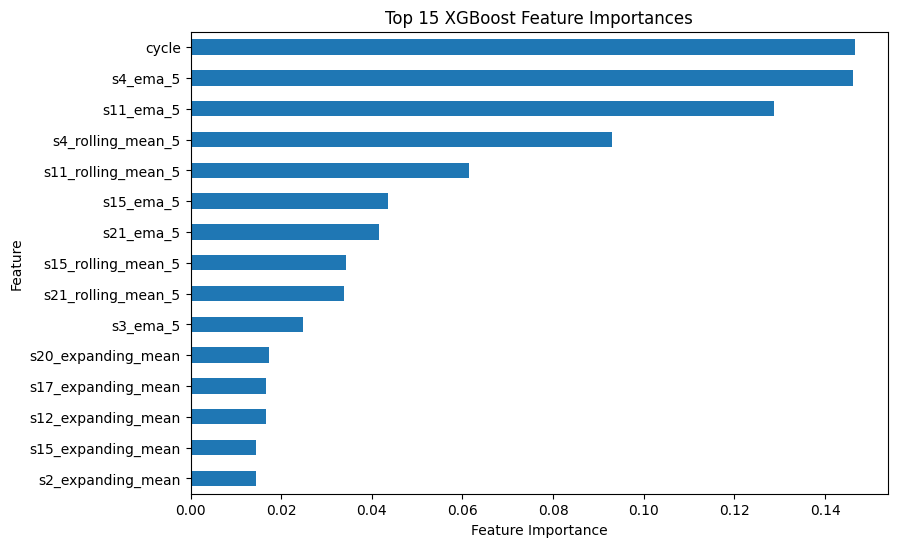

In [30]:
top_xgb_features = (
    xgb_feature_importance
    .head(15)
    .sort_values()
)

plt.figure(figsize=(9, 6))

top_xgb_features.plot(
    kind="barh"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")
plt.show()

# Notebook Summary

This notebook compared two gradient-boosting approaches with the
previously established baseline models.

The evaluation used the same leakage-safe feature set and the same
engine-level train-validation split for every model.

Key findings:

- HistGradientBoosting achieved an MAE of 21.30 cycles and an R² of
  0.799.
- XGBoost achieved an MAE of 21.11 cycles and an R² of 0.804.
- Neither boosting model surpassed Random Forest.
- Both boosting models avoided negative RUL predictions.
- Random Forest remained the strongest validation model with an MAE of
  20.50 cycles, an RMSE of 27.20 cycles, and an R² of 0.828.

No extensive hyperparameter tuning was performed because the current
goal was model-family comparison rather than exhaustive optimization.

The next priority is to evaluate the selected model on the official
NASA FD001 test set using `test_FD001.txt` and `RUL_FD001.txt`.

In [31]:
final_results = model_comparison.copy()

final_results["Rank"] = (
    final_results["MAE"]
    .rank(method="dense")
    .astype(int)
)

final_results = (
    final_results
    .sort_values("Rank")
    .reset_index(drop=True)
)

final_results

,model,MAE,RMSE,R2,Rank
0,Random Forest,20.502000,27.197000,0.828000,1
1,XGBoost,21.105051,29.079475,0.803809,2
2,HistGradientBoosting,21.294995,29.398698,0.799478,3
3,Ridge,28.018000,35.823000,0.702000,4
4,Dummy Mean,55.363000,65.715000,-0.002000,5


## Final Model Selection

XGBoost produced competitive results and no physically invalid negative
RUL predictions, but it did not outperform the Random Forest baseline
on the held-out validation engines.

Compared with Random Forest:

- XGBoost MAE was 2.94% worse.
- XGBoost RMSE was 6.92% worse.
- XGBoost achieved a lower R² score.

Histogram Gradient Boosting showed a similar pattern and also remained
below the Random Forest baseline.

These results indicate that additional model complexity did not provide
a meaningful validation improvement with the current feature set and
configuration.

Random Forest is therefore retained as the current reference model.
This decision is based on validation performance rather than model
complexity or popularity.